In [13]:
from astropy.cosmology import Planck18
%env XLA_PYTHON_CLIENT_ALLOCATOR=platform
import astropy.units as u
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal
import lalsimulation as lalsim
import numpy as np
import os.path as op
import sys
import pandas as pd
import mock_observations

import paths
import jax.numpy as jnp
from tqdm import tqdm, trange
import weighting
import scipy.integrate as sint
import intensity_models
from inspect import getfullargspec
from scipy.interpolate import RegularGridInterpolator

import fisher_snrs
from fisher_snrs import compute_snrs
#import mock_injections
#from mock_injections import *
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.stats import norm, truncnorm

import jax
from importlib import reload 
jax.local_devices()
jax.config.update("jax_enable_x64", True)
import mock_observations

env: XLA_PYTHON_CLIENT_ALLOCATOR=platform


In [2]:
SENSITIVITIES = {'aligo': lalsim.SimNoisePSDaLIGODesignSensitivityP1200087,
                'aplus': lalsim.SimNoisePSDaLIGOAPlusDesignSensitivityT1800042,
                'CE': lalsim.SimNoisePSDCosmicExplorerP1600143}

population_parameters = dict()
config_file = '../reproduce/configs/config2.txt'
#outfile = 'new_mock_inj_cut.h5'#'mock_injections_o3_zp1.h5'

population_parameters = dict()
with open(config_file) as param_file:
    for line in param_file:
        (key, val) = line.split('=')
        population_parameters[key.strip()] = val.strip()
        try:
            population_parameters[key.strip()] = float(val.strip())
        except ValueError:
            pass
snr_threshold = 1
#population_parameters.pop('snr_threshold')
ndraw = int(population_parameters.pop('ndraw', int(5e4)))
sensitivity='o3_PSD'
#sensitivity = population_parameters.pop('sensitivity', 'aligo')
detectors = population_parameters.pop('detectors', 'H1').split(',')
custom_cosmo = intensity_models.FlatwCDMCosmology(population_parameters['h'], population_parameters['Om'], population_parameters['w'], population_parameters['zmax'])
population_parameters['cosmo'] = custom_cosmo
print("Using the following custom population_parameters: " + str(population_parameters))

Using the following custom population_parameters: {'h': 0.674, 'Om': 0.315, 'w': -1.0, 'a': 2.8, 'b': -0.71, 'c': 2.9, 'mpisn': 40.0, 'mbhmax': 45.0, 'sigma': 0.2, 'fpl': 0.21, 'lam': 3.7, 'kappa': 7.0, 'zp': 1.0, 'mpisndot': 0.0, 'zmax': 1.9, 'mbh_min': 5.0, 'delta_m': 2.5, 'beta': -1.0, 'snr_threshold': 1.0, 'cosmo': FlatwCDMCosmology(h=0.674, Om=0.315, w=-1.0, zmax=1.9, ninterp=1024, zinterp=Array([0.00000000e+00, 1.04131475e-03, 2.08371384e-03, ...,
       1.89396980e+00, 1.89698333e+00, 1.90000000e+00],      dtype=float64), dcinterp=Array([0.00000000e+00, 4.63057878e-03, 9.26369560e-03, ...,
       5.15257946e+00, 5.15722323e+00, 5.16186519e+00],      dtype=float64), dlinterp=Array([0.00000000e+00, 4.63540067e-03, 9.28299849e-03, ...,
       1.49114093e+01, 1.49403897e+01, 1.49694090e+01],      dtype=float64), ddlinterp=Array([4.44795252, 4.45502339, 4.46209345, ..., 9.61530365,
       9.61819823, 9.62109004], dtype=float64), vcinterp=Array([0.00000000e+00, 4.15905286e-07, 3.32997

In [3]:
ndraw=int(1e2)
import scipy

In [4]:
class ZPDF(object):
    def __init__(self, lam, kappa, zp, zmax, cosmo):
        self.lam = lam
        self.kappa = kappa
        self.zp = zp

        self.zmax = zmax
        self.cosmo = cosmo

        self.zinterp = np.expm1(np.linspace(np.log(1), np.log(1+self.zmax), 1024))
        self.norm = 1

        unnorm_pdf = self(self.zinterp)
        
        self.norm = 1/np.trapz(unnorm_pdf, self.zinterp)
        self.pdfinterp = unnorm_pdf * self.norm

        self.cdfinterp = sint.cumtrapz(self.pdfinterp, self.zinterp, initial=0)

    def __call__(self, z):
        if self.cosmo == 'default':
            return self.norm*(1+z)**self.lam / (1 + ((1+z)/(1+self.zp))**self.kappa) * Planck18.differential_comoving_volume(z).to(u.Gpc**3/u.sr).value / (1+z)
        else:
            return self.norm*(1+z)**self.lam / (1 + ((1+z)/(1+self.zp))**self.kappa) * (self.cosmo.dVCdz(z)) / (1+z)

    def icdf(self, c):
        return np.interp(c, self.cdfinterp, self.zinterp)
    

class InterpolatedPDF(object):
    def __init__(self, xs, cdfs):
        self.xs = xs
        self.cdfs = cdfs / cdfs[-1]
        self.pdfs = np.diff(cdfs) / np.diff(xs)

    def __call__(self, x):
        x = np.atleast_1d(x)
        i = np.searchsorted(self.xs, x)-1

        return self.pdfs[i]
    
    def icdf(self, c):
        return np.interp(c, self.cdfs, self.xs)

class PowerLawPDF(object):
    def __init__(self, alpha, a, b):
        assert alpha > 1

        self.alpha = alpha
        self.a = a
        self.b = b

        self.norm = (self.a - (self.a/self.b)**self.alpha*self.b)/(self.a*(self.alpha-1))

    def __call__(self, x):
        return (self.a/x)**self.alpha/self.a/self.norm
    
    def icdf(self, c):
        return ((self.a**self.alpha*self.b*c + self.a*self.b**self.alpha*(1-c))/(self.a*self.b)**self.alpha)**(1/(1-self.alpha))


def make_frequency_grid(fmin=20., fmax=2048., deltaf=0.25):
    fs = np.arange(fmin, fmax + deltaf, deltaf)
    return jnp.array(fs), fs[1] - fs[0]

def load_psd(sensitivity, freq_common):
    freqs_psd, sens = np.loadtxt(ASD_FILES[sensitivity], unpack=True)
    psd = sens if sensitivity == "o3_PSD" else sens**2
    psd_interp = interp1d(freqs_psd, psd, bounds_error=False,
                          fill_value=np.inf)
    return jnp.array(psd_interp(np.array(freq_common)))

def build_snr_grid(df_grid, m1_grid, q_grid, detectors, sensitivity, batch_num=400):
    Ngrid = len(df_grid['m1'])
    snr_out = np.zeros(Ngrid)

    num_left = Ngrid
    tot_num  = Ngrid
    num_loops = int(np.trunc(Ngrid / batch_num) + 1)

    for i in range(num_loops):
        if num_left == 0:
            break

        start = int(tot_num - num_left)
        stop  = int(min(start + batch_num, tot_num))

        df_here = {k: v[start:stop] for k, v in df_grid.items()}

        snr_batch = fisher_snrs.compute_snrs_batch(df_here, detectors=detectors, sensitivity=sensitivity, use_antenna=False)
        if i% 10 ==0:
            print("batch done, num left: ", num_left)

        snr_out[start:stop] = np.array(snr_batch)
        num_left -= (stop - start)

    return snr_out.reshape(len(m1_grid), len(q_grid))

In [11]:
grid = np.load("snr_grid_m1det_ext.npz")


m1_grid  = grid["m1_grid"]
q_grid   = grid["q_grid"]
snr_grid = grid["snr_grid"]
dL_fid   = float(grid["dL_fid"])

log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)

/tmp/ipykernel_2060320/4164933813.py:9: RuntimeWarning: divide by zero encountered in log
  log_snr_interp = RegularGridInterpolator((m1_grid, q_grid), np.log(snr_grid), bounds_error=False, fill_value=-np.inf)


## Diagnostic stuff

In [ ]:
ndraw=int(3e6)
a=(0-population_parameters["zp"])/(population_parameters["zp"])
b=(population_parameters["zmax"]-population_parameters["zp"])/(population_parameters["zp"])
zpdf = scipy.stats.truncnorm(a, b, loc=population_parameters["zp"], scale=(population_parameters["zp"]))

a=(population_parameters["mbh_min"]-population_parameters["mpisn"])/(2*population_parameters["mpisn"])
mpdf = scipy.stats.truncnorm(a, np.inf, loc=population_parameters["mpisn"], scale=(2*population_parameters["mpisn"]))

rng = np.random.default_rng()
z = zpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
m = mpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
offset=population_parameters['mbh_min']/m
qpdf = scipy.stats.uniform(loc=0+offset, scale=1-offset) #goes from loc to loc+scale
q = qpdf.ppf(rng.uniform(0, 1, size=ndraw))  

mt=m+q*m
m2 = mt - m
print("calculating pdraws")
pdraw = mpdf.pdf(m)*zpdf.pdf(z)*(1.0 / (1.0 - offset))* qpdf.pdf(q)#*(mtpdf.pdf(mt))*m)
#pdraw = mpdf.pdf(m) * zpdf.pdf(z) * qpdf.pdf(q)

m1d = m * (1 + z)
iota = np.arccos(rng.uniform(low=-1, high=1, size=ndraw))

ra = rng.uniform(low=0, high=2*np.pi, size=ndraw)
dec = np.arcsin(rng.uniform(low=-1, high=1, size=ndraw))

# 0 < psi < pi, uniformly distributed
psi = rng.uniform(low=0, high=np.pi, size=ndraw)
gmst = rng.uniform(low=0, high=2*np.pi, size=ndraw)
m1_det = m * (1 + z)
points = np.column_stack([m1_det, q])
rho0 = np.exp(log_snr_interp(points))

print("assigning spins")

s1x, s1y, s1z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))
s2x, s2y, s2z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))


print("calculating dLs")

dm1sz_dm1ddl = weighting.dm1sz_dm1ddl(z, cosmo=population_parameters['cosmo'])
dL = population_parameters['cosmo'].dL(z)# dL in Gpc 

det = detectors[0]

rho0 = np.exp(log_snr_interp(points))
cosi = np.cos(iota)
zeros=jnp.zeros(len(m))

df = {
    'm1': jnp.array(m),
    'q': jnp.array(q),
    'z': jnp.array(z),
    'dL': jnp.array(dL), #in GPC here
    'm1d': jnp.array(m1d),
    'iota': jnp.array(iota),
    'ra': jnp.array(ra),
    'dec': jnp.array(dec),
    'psi': jnp.array(psi),
    'gmst': jnp.array(gmst),
    's1x': zeros, 
    's1y': zeros, 
    's1z': zeros, #jnp.zeros(len(m)), 
    's2x': zeros, #jnp.zeros(len(m)), 
    's2y': zeros, #jnp.zeros(len(m)), 
    's2z': zeros, #jnp.zeros(len(m)), 
    'pdraw_mqz': jnp.array(pdraw),
    'dm1sz_dm1ddl': jnp.array(dm1sz_dm1ddl),}


# Convert dict of JAX arrays -> dict of NumPy arrays
df_np = {k: np.asarray(v) for k, v in df.items()}

# Build DataFrame
df_pd = pd.DataFrame(df_np)

cosmo = intensity_models.FlatwCDMCosmology(population_parameters['h'], population_parameters['Om'], population_parameters['w'], population_parameters['zmax'])
log_dN_obj = intensity_models.LogDNDMDQDV
pop_params = {key: population_parameters[key] for key in getfullargspec(log_dN_obj)[0][1:] if key in population_parameters.keys()}
log_dN_func=log_dN_obj(**pop_params)
log_dN_vals = log_dN_func(df_pd['m1'].values, df_pd['q'].values, df_pd['z'].values)
log_w = log_dN_vals - jnp.log(pdraw) - jnp.log1p(df_pd['z'].values)+jnp.log(cosmo.dVCdz(df_pd['z'].values)) + jnp.log1p(df_pd['q'].values)

# stable accept-reject
log_w_max = np.nanmax(log_w)
accept_prob = np.exp(log_w - log_w_max)
u = rng.uniform(size=len(accept_prob))
sel_mask = u < accept_prob
accepted_idxs = np.where(sel_mask)[0]
chosen = accepted_idxs
df_det = df_pd.iloc[chosen].copy()

print(f"Retained {len(df_det)} samples after rejection sampling and applying snr cut.")

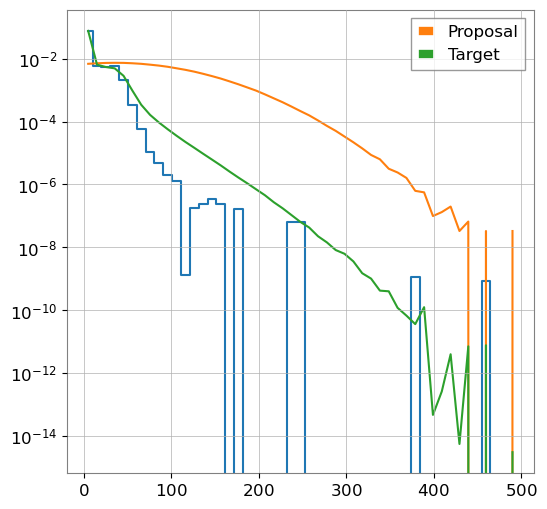

In [183]:
m_bins = np.linspace(m.min(), m.max(), 50)
hist_draw, _ = np.histogram(m, bins=m_bins, density=True)
hist_pop, _ = np.histogram(m, bins=m_bins, weights=np.exp(log_dN_func(m, q, z)), density=True)

hist_m, edges_m = np.histogram(df_det['m1'].values, bins=m_bins, weights=np.exp(log_dN_func(df_det['m1'], df_det['q'], df_det['z'])), density=True)

plt.plot(edges_m[:-1], hist_m, drawstyle='steps-mid')

plt.plot(m_bins[:-1], hist_draw, label='Proposal')
plt.plot(m_bins[:-1], hist_pop, label='Target')
plt.yscale('log')
plt.legend()
plt.show()

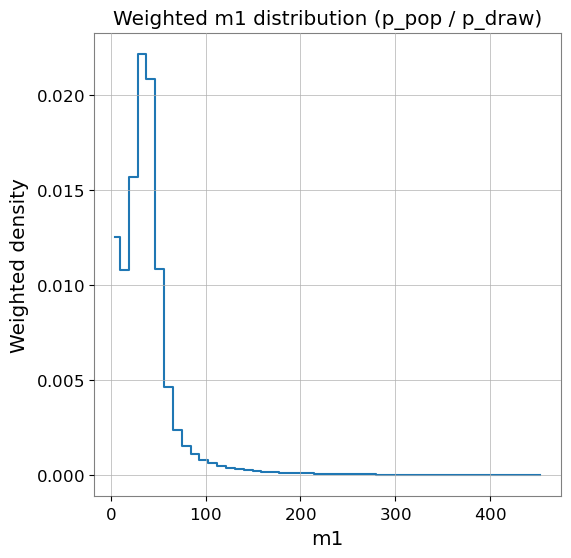

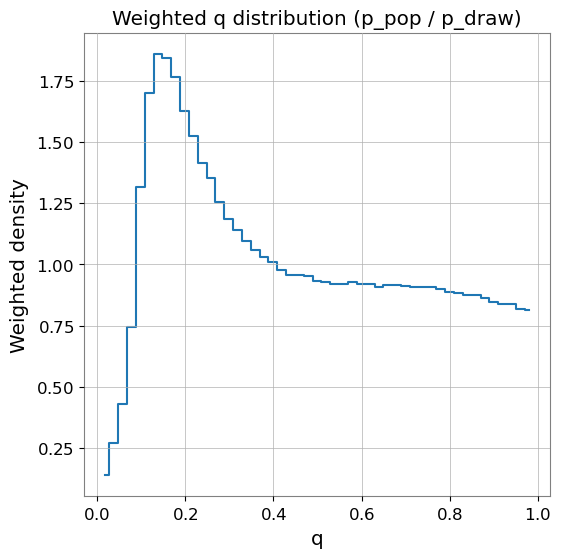

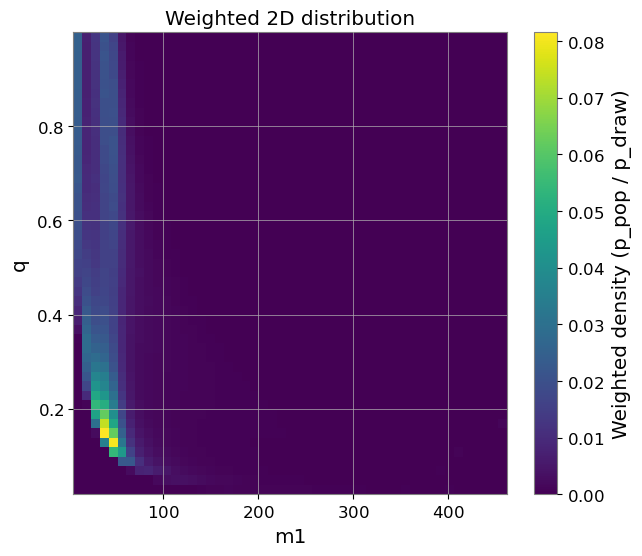

Weighted m1: min, max, median: 5.000002210499709 461.94931384995306 37.39883155648336
Weighted q: min, max, median: 0.01772417858990267 0.9999998659205237 0.20076013714875984


In [44]:
weights = np.exp(log_dN_vals) / pdraw

# Optional: normalize so sum = 1
weights /= np.sum(weights)

# 1D check: m1
m_bins = np.linspace(df_pd['m1'].min(), df_pd['m1'].max(), 50)
hist_m, edges_m = np.histogram(df_pd['m1'].values, bins=m_bins, weights=weights, density=True)
plt.figure()
plt.plot(edges_m[:-1], hist_m, drawstyle='steps-mid')
plt.xlabel('m1')
plt.ylabel('Weighted density')
plt.title('Weighted m1 distribution (p_pop / p_draw)')
plt.show()

# 1D check: q
q_bins = np.linspace(df_pd['q'].min(), df_pd['q'].max(), 50)
hist_q, edges_q = np.histogram(df_pd['q'].values, bins=q_bins, weights=weights, density=True)
plt.figure()
plt.plot(edges_q[:-1], hist_q, drawstyle='steps-mid')
plt.xlabel('q')
plt.ylabel('Weighted density')
plt.title('Weighted q distribution (p_pop / p_draw)')
plt.show()

# 2D check: m1 vs q
m_bins2 = np.linspace(df_pd['m1'].min(), df_pd['m1'].max(), 50)
q_bins2 = np.linspace(df_pd['q'].min(), df_pd['q'].max(), 50)
hist2d, xedges, yedges = np.histogram2d(df_pd['m1'].values, df_pd['q'].values,
                                        bins=[m_bins2, q_bins2], weights=weights, density=True)

plt.figure(figsize=(7,6))
plt.pcolormesh(xedges, yedges, hist2d.T, shading='auto', cmap='viridis')
plt.colorbar(label='Weighted density (p_pop / p_draw)')
plt.xlabel('m1')
plt.ylabel('q')
plt.title('Weighted 2D distribution')
plt.show()

print("Weighted m1: min, max, median:", 
      np.min(df_pd['m1'].values), np.max(df_pd['m1'].values), 
      np.median(np.repeat(df_pd['m1'].values, (weights*1e6).astype(int))))
print("Weighted q: min, max, median:", 
      np.min(df_pd['q'].values), np.max(df_pd['q'].values), 
      np.median(np.repeat(df_pd['q'].values, (weights*1e6).astype(int))))


## Test new SNR

In [102]:
ndraw=int(1e3)
# make this a function
a=(0-population_parameters["zp"])/(population_parameters["zp"])
b=(population_parameters["zmax"]-population_parameters["zp"])/(population_parameters["zp"])
zpdf = scipy.stats.truncnorm(a, b, loc=population_parameters["zp"], scale=(population_parameters["zp"]))

a=(0-population_parameters["mpisn"])/(2*population_parameters["mpisn"])
mpdf = scipy.stats.truncnorm(a, np.inf, loc=population_parameters["mpisn"], scale=(2*population_parameters["mpisn"]))

rng = np.random.default_rng()
z = zpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
m = mpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
offset=population_parameters['mbh_min']/m
qpdf = scipy.stats.uniform(loc=0+offset, scale=1-offset) #goes from loc to loc+scale
q = qpdf.ppf(rng.uniform(0, 1, size=ndraw))  

mt=m+q*m
m2 = mt - m
print("calculating pdraws")
pdraw = mpdf.pdf(m)*zpdf.pdf(z)*(1.0 / (1.0 - offset))#qpdf.pdf(q)#*(mtpdf.pdf(mt))*m)

m1d = m * (1 + z)
iota = np.arccos(rng.uniform(low=-1, high=1, size=ndraw))

ra = rng.uniform(low=0, high=2*np.pi, size=ndraw)
dec = np.arcsin(rng.uniform(low=-1, high=1, size=ndraw))

# 0 < psi < pi, uniformly distributed
psi = rng.uniform(low=0, high=np.pi, size=ndraw)
gmst = rng.uniform(low=0, high=2*np.pi, size=ndraw)
m1_det = m * (1 + z)
points = np.column_stack([m1_det, q])
rho0 = np.exp(log_snr_interp(points))

print("assigning spins")

s1x, s1y, s1z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))
s2x, s2y, s2z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))


print("calculating dLs")

dm1sz_dm1ddl = weighting.dm1sz_dm1ddl(z, cosmo=population_parameters['cosmo'])
dL = population_parameters['cosmo'].dL(z)# dL in Gpc 

det = detectors[0]

Fp0, Fc0 = lal.ComputeDetAMResponse(
    lal.cached_detector_by_prefix[det].response,
    0.0,   # ra
    0.0,   # dec
    0.0,   # psi
    0.0    # gmst
)

#A0 = np.sqrt(Fp0**2 + Fc0**2)
rho0 = np.exp(log_snr_interp(points))
#rho0 /= A0
rho = rho0 * (dL_fid / dL)

Fp = np.zeros(ndraw)
Fc = np.zeros(ndraw)

for i in range(ndraw):
    Fp[i], Fc[i] = lal.ComputeDetAMResponse(lal.cached_detector_by_prefix[detectors[0]].response, ra[i], dec[i], psi[i], gmst[i])

cosi = np.cos(iota)
Theta_sq = (Fp**2 * (1 + cosi**2)**2 / 4 + Fc**2 * cosi**2)
Theta = np.sqrt(Theta_sq)
SNR_comp = rho * Theta
zeros=jnp.zeros(len(m))

df = {
    'm1': jnp.array(m),
    'q': jnp.array(q),
    'z': jnp.array(z),
    'dL': jnp.array(dL), #in GPC here
    'm1d': jnp.array(m1d),
    'iota': jnp.array(iota),
    'ra': jnp.array(ra),
    'dec': jnp.array(dec),
    'psi': jnp.array(psi),
    'gmst': jnp.array(gmst),
    's1x': zeros, 
    's1y': zeros, 
    's1z': zeros, #jnp.zeros(len(m)), 
    's2x': zeros, #jnp.zeros(len(m)), 
    's2y': zeros, #jnp.zeros(len(m)), 
    's2z': zeros, #jnp.zeros(len(m)), 
    'pdraw_mqz': jnp.array(pdraw),
    'dm1sz_dm1ddl': jnp.array(dm1sz_dm1ddl),}

df["SNR"] = SNR_comp

if snr_threshold>0:
    SNR_comp_old = np.zeros(ndraw)
    num_left = ndraw
    tot_num = ndraw
    batch_num=400
    num_loops=int(np.trunc(ndraw/batch_num)+1)
    for i in range(num_loops):
        if num_left==0:
            break
        start=int(tot_num - num_left)
        stop=int(tot_num - num_left + batch_num)
        if num_left > batch_num:
            df_here = {k: v[start:stop] for k, v in df.items()}
        else:
            df_here = {k: v[start:] for k, v in df.items()}
        SNR_batch = fisher_snrs.compute_snrs_batch(df_here, detectors=detectors, sensitivity=sensitivity)
        SNR_batch.block_until_ready()

        SNR_comp_old[start:stop]= SNR_batch
        del df_here, SNR_batch
        if i% 10 ==0:
            print("batch done, num left: ", num_left)
        num_left -= batch_num        
    df['SNR_old']=SNR_comp_old       
                #jnp.asarray(fisher_snrs.compute_snrs_batch(df, detectors=detectors, sensitivity=sensitivity))
        #df['SNR'] = jnp.asarray(fisher_snrs.compute_snrs(df, detectors=detectors, sensitivity=sensitivity))
        #df['SNR_old'] = jnp.asarray(fisher_snrs.compute_snrs_old(pd.DataFrame(df), detectors=detectors, sensitivity=sensitivity))
else:
    df['SNR_old'] = 10000000
    SNR_comp_old=10000000

df['SNR_old'] = SNR_comp_old



# Convert dict of JAX arrays -> dict of NumPy arrays
df_np = {k: np.asarray(v) for k, v in df.items()}

# Build DataFrame
df_pd = pd.DataFrame(df_np)

calculating pdraws
assigning spins
calculating dLs
batch done, num left:  1000


(array([  3.,   5.,   3.,   3.,   8.,  10., 209., 687.,  43.,
          1.]),
 array([0.99990526, 0.99991729, 0.99992931, 0.99994134,
        0.99995337, 0.99996539, 0.99997742, 0.99998945,
        1.00000148, 1.0000135 , 1.00002553]),
 <BarContainer object of 10 artists>)

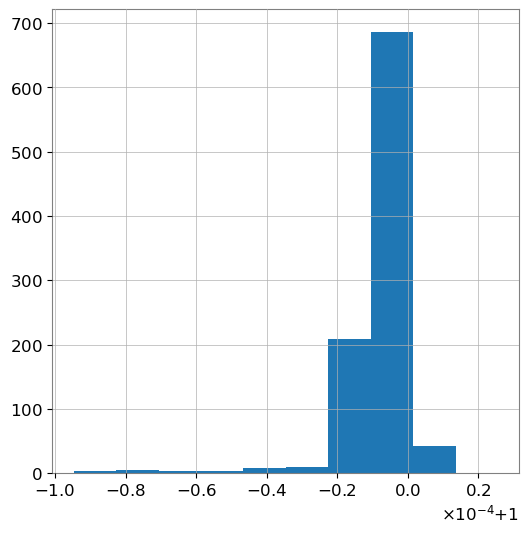

In [103]:
plt.hist(df_pd['SNR']/df_pd['SNR_old'])

## Now gen a population

In [76]:
import gc
gc.collect()

2031

In [6]:
ndraw=int(8e6)
a=(0-5*population_parameters["zp"])/(15*population_parameters["zp"])
#b=(population_parameters["zmax"]-population_parameters["zp"])/(15*population_parameters["zp"])
zpdf = scipy.stats.truncnorm(a, np.inf, loc=5*population_parameters["zp"], scale=(15*population_parameters["zp"]))
rng = np.random.default_rng()

#mpdf = scipy.stats.uniform(loc=0, scale=100000)#f, loc=7.5*population_parameters["mpisn"], scale=(10*population_parameters["mpisn"]))
z = zpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))
#m = mpdf.ppf(rng.uniform(low=0, high=1, size=ndraw))

mmin=0.1
mmax=15000
logm1 = rng.uniform(np.log(mmin), np.log(mmax), ndraw)
m = np.exp(logm1)

offset=0#population_parameters['mbh_min']/m
qpdf = scipy.stats.uniform(loc=0+offset, scale=1-offset) #goes from loc to loc+scale
q = qpdf.ppf(rng.uniform(0, 1, size=ndraw))  

mt=m+q*m
m2 = mt - m
print("calculating pdraws")
pdraw = qpdf.pdf(q)* (1/m) * zpdf.pdf(z) / np.log(mmax/mmin) # mpdf.pdf(m) 

m1d = m * (1 + z)
iota = np.arccos(rng.uniform(low=-1, high=1, size=ndraw))

ra = rng.uniform(low=0, high=2*np.pi, size=ndraw)
dec = np.arcsin(rng.uniform(low=-1, high=1, size=ndraw))

# 0 < psi < pi, uniformly distributed
psi = rng.uniform(low=0, high=np.pi, size=ndraw)
gmst = rng.uniform(low=0, high=2*np.pi, size=ndraw)
m1_det = m * (1 + z)
points = np.column_stack([m1_det, q])
rho0 = np.exp(log_snr_interp(points))

print("assigning spins")

s1x, s1y, s1z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))
s2x, s2y, s2z = 0,0,0#rng.normal(loc=0, scale=0.2/np.sqrt(3), size=(3,ndraw))


print("calculating dLs")

dm1sz_dm1ddl = weighting.dm1sz_dm1ddl(z, cosmo=population_parameters['cosmo'])
dL = population_parameters['cosmo'].dL(z)# dL in Gpc 

det = detectors[0]

#A0 = np.sqrt(Fp0**2 + Fc0**2)
rho0 = np.exp(log_snr_interp(points))
#rho0 /= A0
rho = rho0 * (dL_fid / dL)

#Fp = np.zeros(ndraw)
#Fc = np.zeros(ndraw)

#for i in range(ndraw):
#    Fp[i], Fc[i] = lal.ComputeDetAMResponse(lal.cached_detector_by_prefix[detectors[0]].response, ra[i], dec[i], psi[i], gmst[i])

cosi = np.cos(iota)
#Theta_sq = (Fp**2 * (1 + cosi**2)**2 / 4 + Fc**2 * cosi**2)
#Theta = np.sqrt(Theta_sq)
#SNR_comp = rho * Theta
zeros=jnp.zeros(len(m))

df = {
    'm1': jnp.array(m),
    'q': jnp.array(q),
    'z': jnp.array(z),
    'dL': jnp.array(dL), #in GPC here
    'm1d': jnp.array(m1d),
    'iota': jnp.array(iota),
    'ra': jnp.array(ra),
    'dec': jnp.array(dec),
    'psi': jnp.array(psi),
    'gmst': jnp.array(gmst),
    's1x': zeros, 
    's1y': zeros, 
    's1z': zeros, #jnp.zeros(len(m)), 
    's2x': zeros, #jnp.zeros(len(m)), 
    's2y': zeros, #jnp.zeros(len(m)), 
    's2z': zeros, #jnp.zeros(len(m)), 
    'pdraw_mqz': jnp.array(pdraw),
    'dm1sz_dm1ddl': jnp.array(dm1sz_dm1ddl),
    'SNR_0': jnp.array(rho),
    'ndraw': zeros+ndraw}

#df["SNR"] = SNR_comp

# Convert dict of JAX arrays -> dict of NumPy arrays
df_np = {k: np.asarray(v) for k, v in df.items()}

# Build DataFrame
df_pd = pd.DataFrame(df_np)

calculating pdraws
assigning spins
calculating dLs


In [7]:
df_det=df_pd
Fp = np.zeros(len(df_det))
Fc = np.zeros(len(df_det))

ra = rng.uniform(low=0, high=2*np.pi, size=len(df_det))
dec = np.arcsin(rng.uniform(low=-1, high=1, size=len(df_det)))


psi = rng.uniform(low=0, high=np.pi, size=len(df_det))
gmst = rng.uniform(low=0, high=2*np.pi, size=len(df_det))
iota = np.arccos(rng.uniform(low=-1, high=1, size=len(df_det)))

for i in range(len(df_det)):
    Fp[i], Fc[i] = lal.ComputeDetAMResponse(lal.cached_detector_by_prefix[detectors[0]].response, ra[i], dec[i], psi[i], gmst[i])

cosi = np.cos(iota)
Theta_sq = (Fp**2 * (1 + cosi**2)**2 / 4 + Fc**2 * cosi**2)
Theta = np.sqrt(Theta_sq)
SNR_comp = df_det['SNR_0'] * Theta
df_det['SNR']=SNR_comp
df_det['Theta']=Theta
df_det = df_det[df_det['SNR'] > 1]



In [8]:
snr_threshold=8

In [9]:
df_det=df_det.drop(columns=['SNR_0'])
df_det['SNR_OBS'] = df_det['SNR'] + rng.normal(loc=0, scale=np.sqrt(1), size=len(df_det))
df_det = df_det[df_det['SNR_OBS'] > snr_threshold]
len(df_det)

19414

In [107]:
np.max(df_det['z'])

np.float64(1.091009403411681)

In [108]:
np.max(df_det['m1d'])

np.float64(934.8164867677739)

In [109]:
np.max(df_det['q'])

np.float64(0.9999888976739424)

In [110]:
np.min(df_det['q'])

np.float64(0.00957221735509517)

In [10]:
df_det['dm1sz_dm1ddl']= weighting.dm1sz_dm1ddl(df_det['z'].values)#1/ ((1+sel_samples['z'].values))*cosmo.ddL_dz(sel_samples['z'].values)

print(f"Retained {len(df_det)} samples after rejection sampling and applying snr cut.")
df_det.to_hdf('sel_samps_mine.h5', key='samples', mode='a', format='table', append=False)


Retained 19414 samples after rejection sampling and applying snr cut.


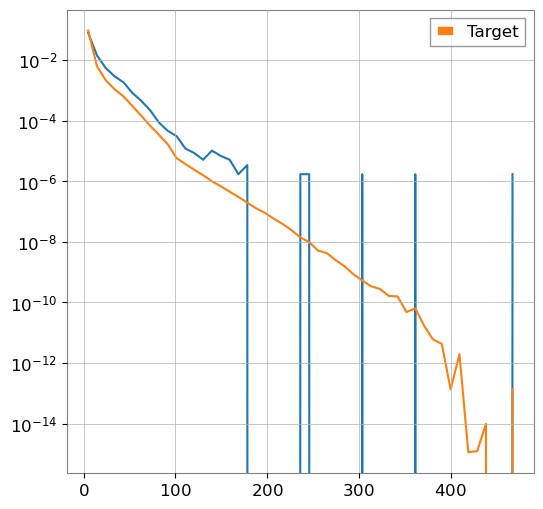

In [21]:
m_bins = np.linspace(m.min(), m.max(), 50)
hist_draw, _ = np.histogram(m, bins=m_bins, density=True)
hist_pop, _ = np.histogram(m, bins=m_bins, weights=np.exp(log_dN_func(m, q, z)), density=True)

hist_m, edges_m = np.histogram(df_det['m1'].values, bins=m_bins, density=True)

plt.plot(edges_m[:-1], hist_m)

#plt.plot(m_bins[:-1], hist_draw, label='Proposal')
plt.plot(m_bins[:-1], hist_pop, label='Target')
plt.yscale('log')
plt.legend()
plt.show()

Retained 28 samples after rejection sampling and applying snr cut.


/tmp/ipykernel_450483/3911301377.py:19: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_det['SNR']=SNR_comp


### Plots to check

In [9]:
z_space=np.linspace(0, 1.9, 40)
def R_of_z(z, lam=population_parameters['lam'], kappa=population_parameters['kappa'], zp=population_parameters['zp']):
    num=(1+z)**lam
    denom=1+(((1+z)/(1+zp))**kappa)
    dVcdz=cosmo.dVCdz(z)
    return num/denom* dVcdz / (1+z)
Rs=R_of_z(z_space)

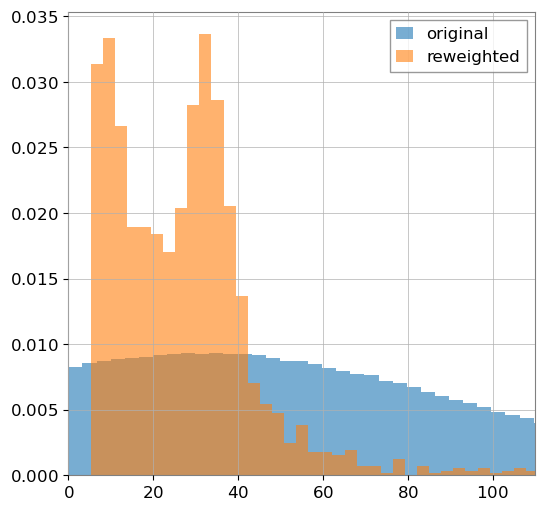

In [191]:
plt.hist(df_pd['m1'], density=True, bins=100, alpha=.6, label='original');
plt.hist(df_det['m1'],density=True, bins=100, alpha=.6, label='reweighted');
plt.legend()
plt.xlim(0, 110);

In [ ]:
# lower c value perferred - we have too many high mass samples/medium mass samples
# lower a perferred - we have too many medium mass samples, dropoff should be sharper for a>1
# flp too high - we have too many high mass samples
# lam too low - we dont have enough mergers at low redshift

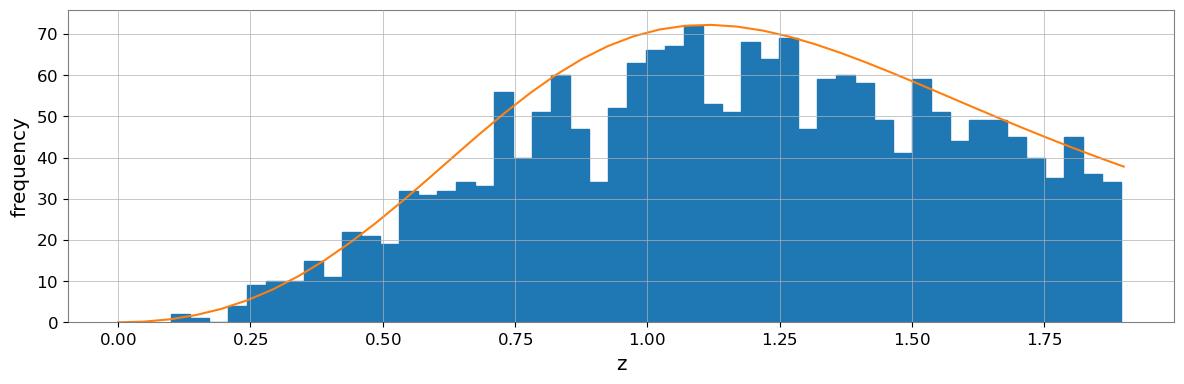

In [135]:
plt.figure(figsize=(12, 4))
plt.hist(jnp.array(df_det['z'].astype(float)), bins=50, histtype='step',  fill=True)
plt.plot(z_space, .06*Rs)
plt.xlabel("z")
plt.ylabel("frequency")
#plt.yscale('log')
#plt.xlim(0, 150)
plt.tight_layout()
plt.show()

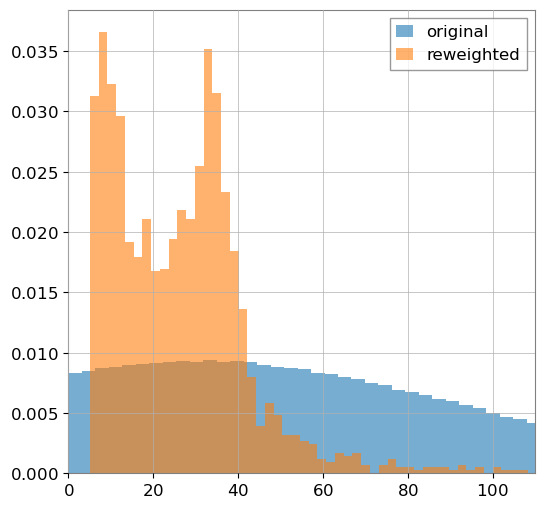

In [136]:
plt.hist(df_pd['m1'], density=True, bins=100, alpha=.6, label='original');
plt.hist(df_det['m1'],density=True, bins=100, alpha=.6, label='reweighted');
plt.legend()
plt.xlim(0, 110);

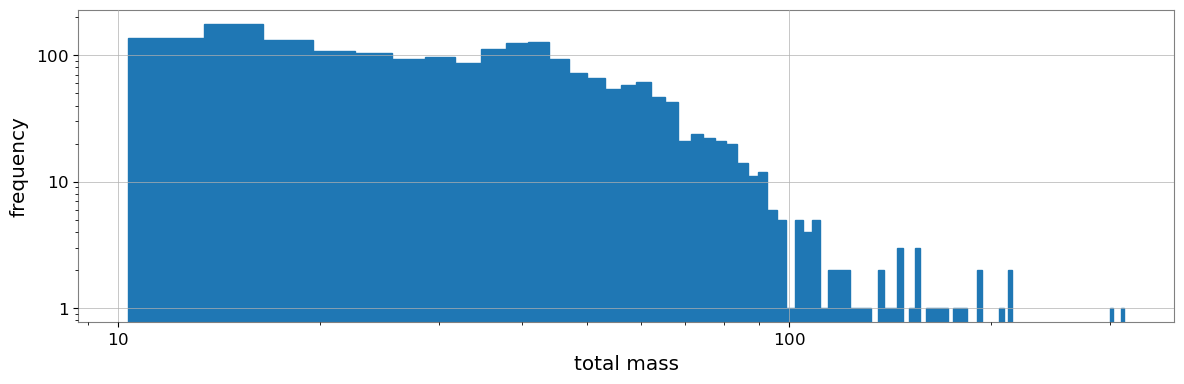

In [192]:
plt.figure(figsize=(12, 4))
plt.hist(jnp.array(df_det['m1'].astype(float))+ jnp.array(df_det['m1'].astype(float)*df_det['q'].astype(float)),
         bins=100, histtype='step',  fill=True)
tot_mass_ex=np.linspace(45, 80, 10)
plt.xlabel("total mass")
plt.ylabel("frequency")
plt.yscale('log')
plt.xscale('log')
#plt.xlim(0, 150)
plt.tight_layout()
plt.show()

## Redoing SNR calc with the emulator

In [83]:
inj = pd.read_hdf('injections/confg3_inj.h5', key='true_parameters')
inj.keys()

Index(['m1', 'q', 'z', 'dL', 'm1d', 'iota', 'ra', 'dec', 'psi', 'gmst', 's1x',
       's1y', 's1z', 's2x', 's2y', 's2z', 'pdraw_mqz', 'dm1sz_dm1ddl', 'SNR',
       'pdraw_sel'],
      dtype='object')

In [36]:
# make this a function
#detection_threshold=8

#inj = pd.read_hdf('mock_injections_paper_old.h5', key='true_parameters')[0:200]
m=np.array(inj['m1'])
z=np.array(inj['z'])
q=np.array(inj['q'])
mt=m+q*m

m2 = mt - m
m1d = m * (1 + z)
iota =np.array(inj['iota'])
ra =  np.array(inj['ra'])
dec = np.array(inj['dec'])
psi =  np.array(inj['psi'])
gmst =  np.array(inj['gmst'])
pdraw=np.array(inj['pdraw_mqz'])
m1_det = m * (1 + z)
points = np.column_stack([m1_det, q])
rho0 = np.exp(log_snr_interp(points))

s1x, s1y, s1z = 0,0,0
s2x, s2y, s2z = 0,0,0
dm1sz_dm1ddl = weighting.dm1sz_dm1ddl(z, cosmo=population_parameters['cosmo'])
dL = inj['dL']

det = detectors[0]

rho0 = np.exp(log_snr_interp(points))
rho = rho0 * (dL_fid / dL)
Fp = np.zeros(len(m))
Fc = np.zeros(len(m))

for i in range(len(m)):
    Fp[i], Fc[i] = lal.ComputeDetAMResponse(lal.cached_detector_by_prefix[detectors[0]].response, ra[i], dec[i], psi[i], gmst[i])

cosi = np.cos(iota)
Theta_sq = (Fp**2 * (1 + cosi**2)**2 / 4 + Fc**2 * cosi**2)
Theta = np.sqrt(Theta_sq)
SNR_comp = rho * Theta
zeros=jnp.zeros(len(m))

df = {
    'm1': jnp.array(m),
    'q': jnp.array(q),
    'z': jnp.array(z),
    'dL': jnp.array(dL), #in GPC here
    'm1d': jnp.array(m1d),
    'iota': jnp.array(iota),
    'ra': jnp.array(ra),
    'dec': jnp.array(dec),
    'psi': jnp.array(psi),
    'gmst': jnp.array(gmst),
    's1x': zeros, 
    's1y': zeros, 
    's1z': zeros, #jnp.zeros(len(m)), 
    's2x': zeros, #jnp.zeros(len(m)), 
    's2y': zeros, #jnp.zeros(len(m)), 
    's2z': zeros, #jnp.zeros(len(m)), 
    'pdraw_mqz': jnp.array(pdraw),
    'dm1sz_dm1ddl': jnp.array(dm1sz_dm1ddl),}

df["SNR"] = SNR_comp

# Convert dict of JAX arrays -> dict of NumPy arrays
df_np = {k: np.asarray(v) for k, v in df.items()}

# Build DataFrame
df_pd = pd.DataFrame(df_np)

print(f"Retained {len(df_pd)} samples after rejection sampling and applying snr cut.")
df_pd.to_hdf('injections/con3_SNRcomp.h5', key='true_parameters', mode='a', format='table', append=False)


Retained 1198 samples after rejection sampling and applying snr cut.
